# **LIBRARY**

## Importing File


In [18]:
# LOADING DATA AND DATA EXTRACTION
import zipfile
import os

## Pre-Processing

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Training

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

## Evaluation

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

# **CONFIGURATIONS**

## Importing File

In [22]:
ZIP_PATH = "mnist.zip"
EXTRACT_PATH = "mnist_dataset"

## Pre-Processing

In [23]:
VALIDATION_SPLIT = 0.2
TARGET_SIZE = (224,224)
BATCH_SIZE = 32

# **IMPORTING FILE**

In [24]:
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

In [25]:
train_dir = os.path.join(EXTRACT_PATH, "train")
test_dir = os.path.join(EXTRACT_PATH, "test")
print("Train folder:", train_dir)
print("Test folder:", test_dir)

Train folder: mnist_dataset/train
Test folder: mnist_dataset/test


# **PRE-PROCESSING**

## 1. Create Image Data Generator

In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
    )
test_datagen = ImageDataGenerator(
    rescale=1./255
    )

## 2. Create Generator
Move folder data to generator variable using datagen

In [27]:
# Training Set
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
    )

Found 800 images belonging to 10 classes.


In [28]:
# Validation Set
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
    )

Found 200 images belonging to 10 classes.


In [29]:
# Test Set
test_generator = test_datagen.flow_from_directory(
    train_dir,
    target_size=TARGET_SIZE
    )

Found 1000 images belonging to 10 classes.


# **TRAINING**

In [30]:
model = Sequential()

## Model Architechture

In [31]:
model.add(
    Conv2D(
        32,
         (3,3),
        activation='relu',
        input_shape=(224,224 ,3)
        )
)
model.add(
    MaxPooling2D(2,2)
)
model.add(
    Conv2D(
        64,
         (3,3),
        activation='relu'
        )
)
model.add(
    MaxPooling2D(2,2)
)
model.add(
    Conv2D(
        128,
         (3,3),
        activation='relu'
        )
)
model.add(
    MaxPooling2D(2,2)
)
model.add(
    Flatten()
    )
model.add(
    Dense(
        128,
        activation='relu'
        ))
model.add(
    Dropout(0.0)
    )
model.add(
    Dense(
        10,
        activation='softmax'
        ))

### Summary

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [34]:
history = model.fit(
     train_generator,
     validation_data=validation_generator,
     epochs=10
 )

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.6212 - loss: 1.1954 - val_accuracy: 0.7900 - val_loss: 0.6503
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9237 - loss: 0.2607 - val_accuracy: 0.8350 - val_loss: 0.4853
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9787 - loss: 0.0633 - val_accuracy: 0.8700 - val_loss: 0.5496
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9937 - loss: 0.0168 - val_accuracy: 0.8500 - val_loss: 0.7841
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9962 - loss: 0.0069 - val_accuracy: 0.8650 - val_loss: 0.7645
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9975 - loss: 0.0057 - val_accuracy: 0.8600 - val_loss: 0.7461
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9987 - loss: 0.0024 - val_accuracy: 0.8600 - val_loss: 0.7881
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8550 

# **EVALUATION**

## Model Accuracy and Loss

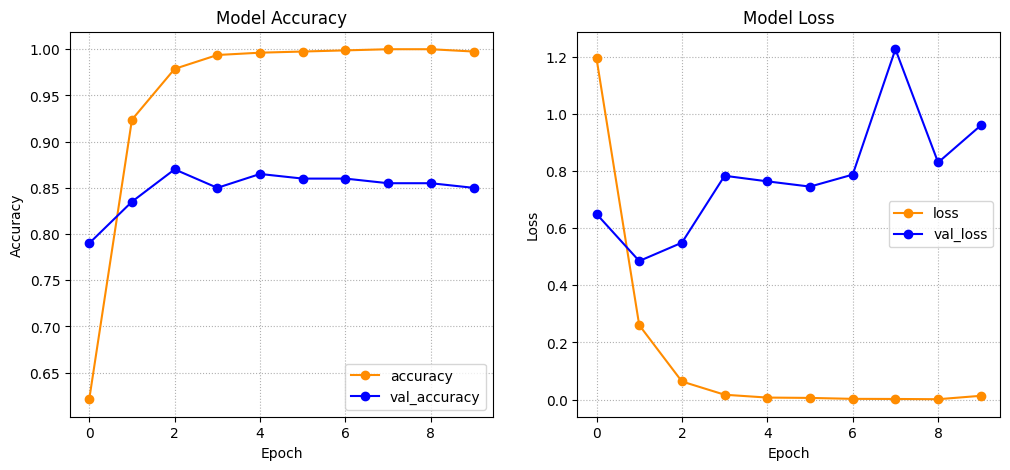

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Graph
axes[0].plot(
    history.history['accuracy'],
    "o-",
    label="accuracy",
    color="darkorange"
)

axes[0].plot(
    history.history['val_accuracy'],
    "o-",
    label="val_accuracy",
    color="blue"
)

axes[0].grid(True, linestyle=":")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Model Accuracy")
axes[0].legend()

# Loss Graph
axes[1].plot(
    history.history['loss'],
    "o-",
    label="loss",
    color="darkorange"
)

axes[1].plot(
    history.history['val_loss'],
    "o-",
    label="val_loss",
    color="blue"
)

axes[1].grid(True, linestyle=":")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Model Loss")
axes[1].legend()

## Evaluate Model

In [36]:
loss,accuracy = model.evaluate(test_generator)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9580 - loss: 0.2316


In [37]:
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss*100:2f}%")

Test Accuracy: 95.80%
Test Loss: 23.162833%


## Evaluate Individual Image

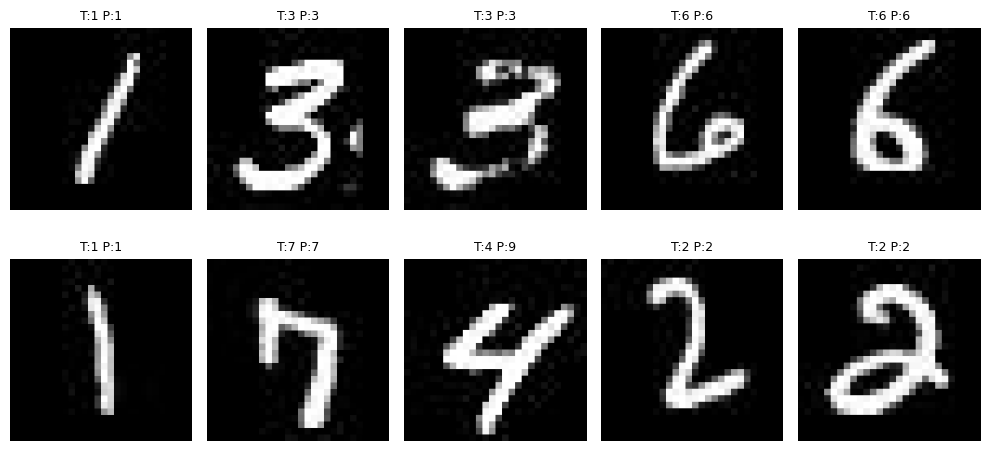

In [38]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = test_generator[0]
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i]
    y_true = np.argmax(labels[i])
    y_pred = np.argmax(
        model.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )
    )
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"T:{y_true} P:{y_pred}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Confusion Matrix

In [39]:
test_generator.reset()

In [40]:
y_true = []
y_pred = []

In [41]:
for i in range(len(test_generator)):
    images, labels = test_generator[i]
    preds = model.predict(images, verbose=0)

    y_true.extend(
        np.argmax(labels, axis=1)
    )
    y_pred.extend(
        np.argmax(preds, axis=1)
    )

In [42]:
ytrue=np.array(y_true)
ypred=np.array(y_pred)

In [43]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[100   0   0   0   0   0   0   0   0   0]
 [  0  99   1   0   0   0   0   0   0   0]
 [  0   0  98   0   0   0   1   0   1   0]
 [  0   0  11  85   0   1   0   1   1   1]
 [  0   0   0   0  97   0   1   0   1   1]
 [  0   0   1   0   0  95   1   0   3   0]
 [  0   0   0   0   0   1  98   0   1   0]
 [  0   0   2   0   0   0   0  98   0   0]
 [  0   1   7   0   1   1   0   0  90   0]
 [  0   0   0   0   1   0   0   1   0  98]]


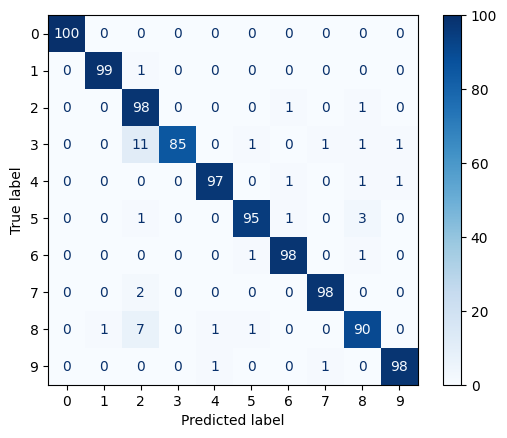

In [44]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot(cmap='Blues')

## Classification Report

In [45]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       0.99      0.99      0.99       100
           2       0.82      0.98      0.89       100
           3       1.00      0.85      0.92       100
           4       0.98      0.97      0.97       100
           5       0.97      0.95      0.96       100
           6       0.97      0.98      0.98       100
           7       0.98      0.98      0.98       100
           8       0.93      0.90      0.91       100
           9       0.98      0.98      0.98       100

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



# Export Model

In [46]:
SAVE_PATH = "mnist_cnn.keras"
model.save(SAVE_PATH)